# Нейросеть для предсказания калорийности блюд

🎯 **Цель проекта**

Создать и обучить нейросетевую модель, способную оценивать калорийность блюда на основе его фотографии и списка ингредиентов.
Для использования в fitness- и health-приложениях для автоматической оценки рациона питания и контроля за калорийностью.

📊 **Описание данных**

В проекте используется датасет объёмом около 1.3 ГБ, включающий:

**data/ingredients.csv** — справочник ингредиентов

- id — идентификатор ингредиента

- ingr — название ингредиента

**data/dish.csv** — информация о блюдах

- dish_id — уникальный ID блюда

- total_calories — общая калорийность (целевая переменная)

- total_mass — масса блюда (г)

- ingredients — список ингредиентов в формате ingr_0000000122;ingr_0000000026;...

- split — разметка для разделения на train/test

**data/images/** — фотографии блюд, где каждая папка названа по dish_id и содержит файл rgb.png.

🧠 **Задача моделирования**

Необходимо построить мультимодальную модель (объединяющую визуальные и текстовые признаки), которая по данным изображения и ингредиентов предсказывает калорийность блюда.
Финальная модель должна демонстрировать MAE < 50 на тестовой выборке.

## Этап 1. EDA

### Загрузка данных

In [1]:
from pathlib import Path
import os
import sys
import math
import re
import random
import shutil
from tqdm import tqdm
from functools import partial
from collections import Counter
from dataclasses import dataclass
from functools import partial

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats
from dotenv import load_dotenv

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
from transformers import (
    AutoModel,
    AutoTokenizer,
    AutoImageProcessor
)

# === Загрузка переменных из .env ===
load_dotenv() 

# === Получаем путь из переменной окружения ===
env_path = os.getenv("DLE_PROJECT_PATH")
if env_path is None:
    raise EnvironmentError("❌ Переменная окружения DLE_PROJECT_PATH не задана!")

BASE_DIR = Path(env_path)
DATA_DIR = BASE_DIR / "data"
CSV_DISH = DATA_DIR / "dish.csv"
CSV_INGR = DATA_DIR / "ingredients.csv"
IMAGES_DIR = DATA_DIR / "images"

print(f"📁 Базовая директория данных: {BASE_DIR}")

# Добавляем путь к src
SRC_PATH = BASE_DIR / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# === Local imports ===
from config import config
from dataset import MultimodalDataset, get_transforms, collate_fn, create_dataloaders
from utils import set_requires_grad
from model import MultimodalModel
from utils import train_regression


📁 Базовая директория данных: C:\Files\AI\DLE\projects\dle_sprint_4


In [2]:
# === Проверка наличия файлов ===
for path in [CSV_DISH, CSV_INGR, IMAGES_DIR]:
    if not path.exists():
        raise FileNotFoundError(f"❌ Не найден путь: {path}")
print("✅ Все пути к данным найдены")

# === Загрузка таблиц ===
dish_df = pd.read_csv(CSV_DISH)
ingredients_df = pd.read_csv(CSV_INGR)

print(f"✅ dish.csv: {dish_df.shape[0]:,} строк, {dish_df.shape[1]} столбцов")
print(f"✅ ingredients.csv: {ingredients_df.shape[0]:,} строк, {ingredients_df.shape[1]} столбцов")

✅ Все пути к данным найдены
✅ dish.csv: 3,262 строк, 5 столбцов
✅ ingredients.csv: 555 строк, 2 столбцов


In [3]:
# Просмотр первых строк и информации о таблицах
display(dish_df.head(3))
dish_df.info()

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.6+ KB


In [4]:
display(ingredients_df.head(3))
ingredients_df.info()

,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB


In [5]:
# Поиск дубликатов в таблицах
print(f"❗ Дубликаты в dish_df: {dish_df.duplicated().sum()}")
print(f"❗ Дубликаты в ingredients_df: {ingredients_df.duplicated().sum()}")


❗ Дубликаты в dish_df: 0
❗ Дубликаты в ingredients_df: 0


### EDA

In [6]:
# Структура и статистика блюд
dish_df.describe()[['total_calories', 'total_mass']]

,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


- Средняя калорийность — около 255 ккал, что соответствует лёгким приёмам пищи.

- Средняя масса — ~215 г, то есть порции довольно небольшие.

Есть аномально большие значения:

- максимум 3943 ккал и 3051 г — вероятно, ошибка в данных или блюдо-комбо.

- Минимальные значения (0 ккал, 1 г) также указывают на возможные некорректные записи.

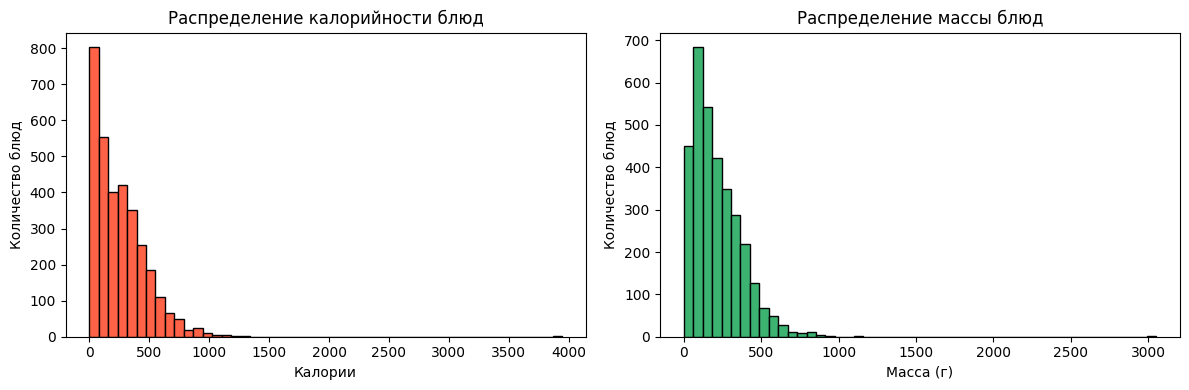

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Калорийность ---
axes[0].hist(dish_df['total_calories'], bins=50, color='tomato', edgecolor='black')
axes[0].set_title('Распределение калорийности блюд')
axes[0].set_xlabel('Калории')
axes[0].set_ylabel('Количество блюд')

# --- Масса ---
axes[1].hist(dish_df['total_mass'], bins=50, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Распределение массы блюд')
axes[1].set_xlabel('Масса (г)')
axes[1].set_ylabel('Количество блюд')

plt.tight_layout()
plt.show()

🔥 Калорийность выбросы: 59 / 3262
⚖️ Масса выбросы: 57 / 3262
📊 Всего выбивающихся блюд: 105


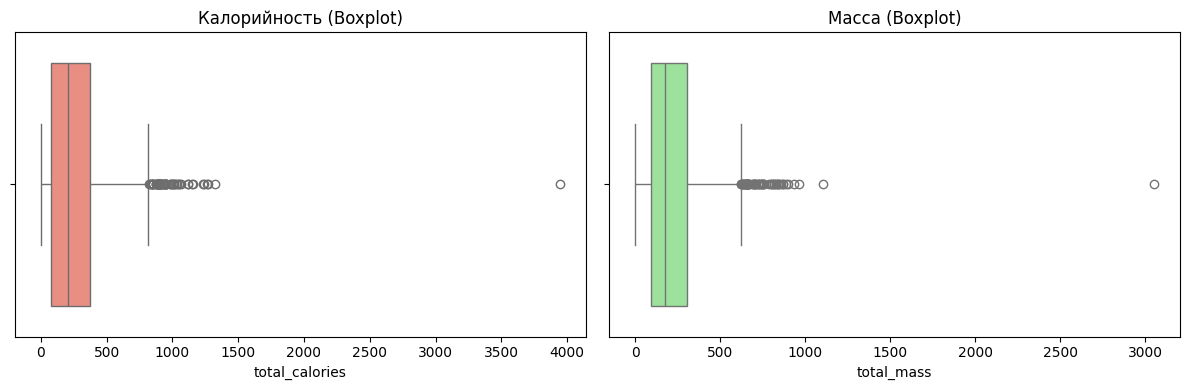

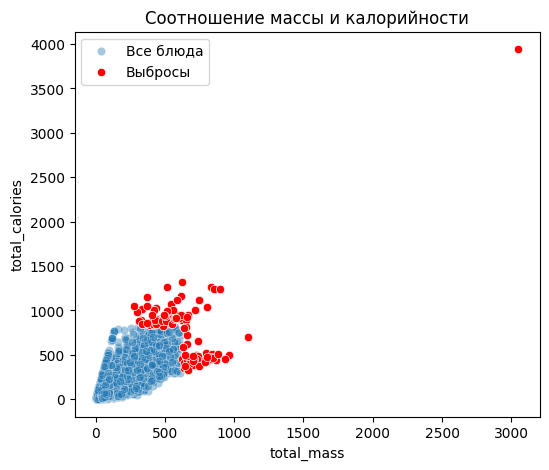

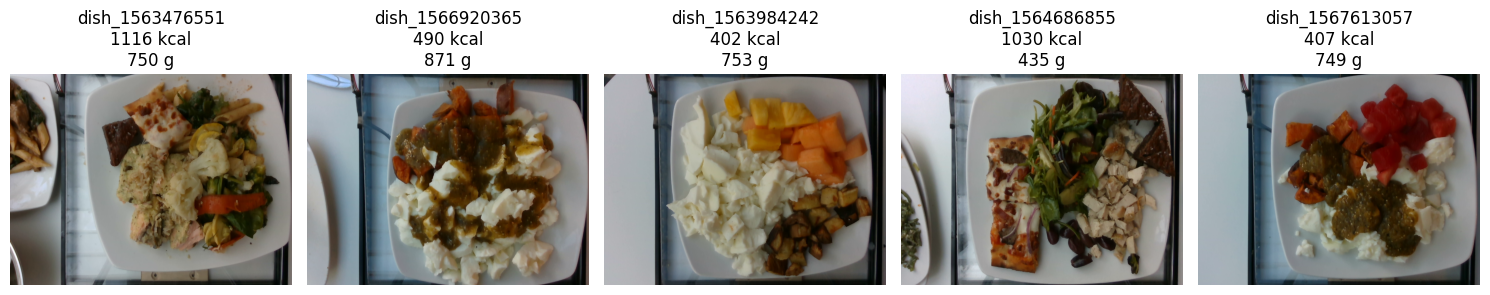

In [8]:
# === 1. Функция для выделения выбросов (IQR) ===
def detect_outliers_iqr(series):
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return series[mask]

# === 2. Находим выбросы ===
outliers_cal = detect_outliers_iqr(dish_df['total_calories'])
outliers_mass = detect_outliers_iqr(dish_df['total_mass'])

outlier_df = dish_df[
    (dish_df['total_calories'].isin(outliers_cal)) |
    (dish_df['total_mass'].isin(outliers_mass))
].copy()

print(f"🔥 Калорийность выбросы: {len(outliers_cal)} / {len(dish_df)}")
print(f"⚖️ Масса выбросы: {len(outliers_mass)} / {len(dish_df)}")
print(f"📊 Всего выбивающихся блюд: {len(outlier_df)}")

# === 3. Boxplot для наглядности ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=dish_df['total_calories'], ax=axes[0], color='salmon')
axes[0].set_title("Калорийность (Boxplot)")
sns.boxplot(x=dish_df['total_mass'], ax=axes[1], color='lightgreen')
axes[1].set_title("Масса (Boxplot)")
plt.tight_layout()
plt.show()

# === 4. Scatter-график для связи масса–калорийность ===
plt.figure(figsize=(6, 5))
sns.scatterplot(data=dish_df, x='total_mass', y='total_calories', alpha=0.4, label='Все блюда')
sns.scatterplot(data=outlier_df, x='total_mass', y='total_calories', color='red', label='Выбросы')
plt.title("Соотношение массы и калорийности")
plt.legend()
plt.show()

# === 5. Просмотр изображений для выбросов ===
sample_outliers = outlier_df.head(5)  # можно изменить число
fig, axes = plt.subplots(1, len(sample_outliers), figsize=(15, 4))

for ax, (_, row) in zip(axes, sample_outliers.iterrows()):
    folder = IMAGES_DIR / row['dish_id']
    img_path = folder / "rgb.png"
    if img_path.exists():
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{row['dish_id']}\n{row['total_calories']:.0f} kcal\n{row['total_mass']:.0f} g")
    else:
        ax.text(0.5, 0.5, "Нет фото", ha='center', va='center')
        ax.axis("off")

plt.tight_layout()
plt.show()

🥗 Блюд с 0 калорий: 2
🔥 Блюд с максимумом (3943.33): 1


,dish_id,total_calories,total_mass,split
263,dish_1557861216,0.0,1.0,test
2652,dish_1556575700,0.0,86.0,train


,dish_id,total_calories,total_mass,split
1518,dish_1560974769,3943.325195,3051.0,train


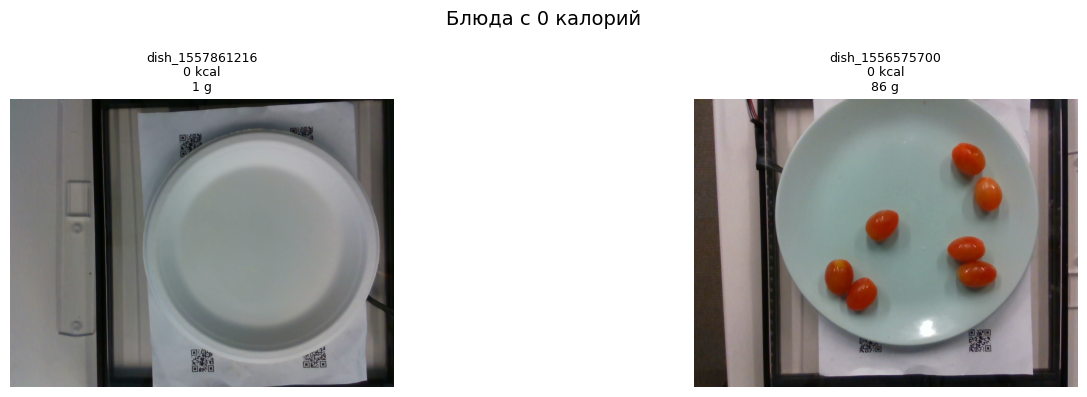

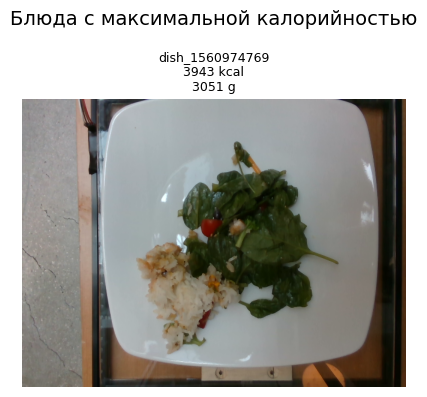

In [9]:
# === 1. Фильтрация нужных значений ===
zero_cal = dish_df[dish_df['total_calories'] == 0]
max_cal = dish_df[dish_df['total_calories'] == dish_df['total_calories'].max()]

print(f"🥗 Блюд с 0 калорий: {len(zero_cal)}")
print(f"🔥 Блюд с максимумом ({dish_df['total_calories'].max():.2f}): {len(max_cal)}")

# === 2. Проверим характеристики этих блюд ===
display(zero_cal[['dish_id', 'total_calories', 'total_mass', 'split']])
display(max_cal[['dish_id', 'total_calories', 'total_mass', 'split']])

# === 3. Визуализируем изображения ===
def show_dishes(df, title):
    n = min(5, len(df))
    fig, axes = plt.subplots(1, n, figsize=(15, 4))
    fig.suptitle(title, fontsize=14)
    
    # — Унифицируем axes: превращаем в список даже если он один
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, df.iterrows()):
        img_path = IMAGES_DIR / row['dish_id'] / "rgb.png"
        if img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"{row['dish_id']}\n{row['total_calories']:.0f} kcal\n{row['total_mass']:.0f} g", fontsize=9)
        else:
            ax.text(0.5, 0.5, "Нет фото", ha="center", va="center", fontsize=10)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

# Повторим вызовы
show_dishes(zero_cal, "Блюда с 0 калорий")
show_dishes(max_cal, "Блюда с максимальной калорийностью")

In [10]:
# Список блюд
dish_ids = ['dish_1557861216', 'dish_1556575700', 'dish_1560974769']

# Функция для получения ингредиентов
def get_ingredients(dish_id):
    row = dish_df[dish_df['dish_id'] == dish_id]
    if row.empty:
        return []
    codes = row['ingredients'].values[0].split(';')
    ids = [int(c.replace('ingr_', '')) for c in codes]
    return ingredients_df[ingredients_df['id'].isin(ids)]['ingr'].tolist()

# Получаем ингредиенты для всех блюд
dish_ingredients = {dish_id: get_ingredients(dish_id) for dish_id in dish_ids}

dish_ingredients

{'dish_1557861216': ['plate only'],
 'dish_1556575700': ['plate only'],
 'dish_1560974769': ['white rice',
  'tomatoes',
  'spinach (raw)',
  'corn',
  'cheese',
  'onions',
  'garlic',
  'chili',
  'tortilla chips',
  'salt',
  'black beans',
  'lime',
  'sour cream',
  'cherry tomatoes']}

Блюдо dish_1557861216 действительно является пустой тарелкой, как и на изображении. Остальные два явно ошибочные

In [11]:
# 1️⃣ Блюда для удаления
remove_dishes = ['dish_1556575700', 'dish_1560974769']

# 2️⃣ Удаляем из dish_df
dish_df = dish_df[~dish_df['dish_id'].isin(remove_dishes)].reset_index(drop=True)

# 3️⃣ Удаляем ингредиенты, которые больше нигде не встречаются
# Получаем все коды ингредиентов этих блюд
ingr_codes_to_remove = []
for dish_id in remove_dishes:
    row = dish_df[dish_df['dish_id'] == dish_id]
    if not row.empty:
        codes = row['ingredients'].values[0].split(';')
        ingr_codes_to_remove.extend([int(c.replace('ingr_', '')) for c in codes])

# Удаляем их из ingredients_df
ingredients_df = ingredients_df[~ingredients_df['id'].isin(ingr_codes_to_remove)].reset_index(drop=True)

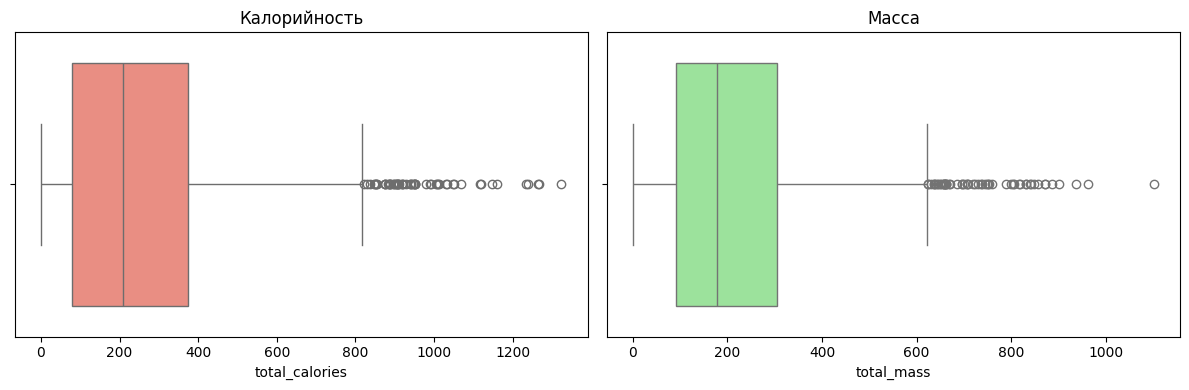

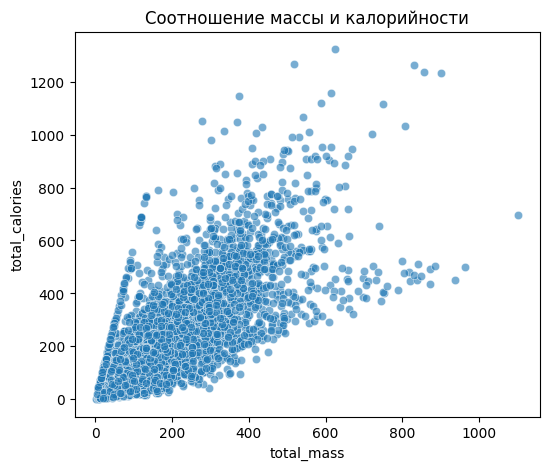

In [12]:
# === Boxplot ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=dish_df['total_calories'], ax=axes[0], color='salmon')
axes[0].set_title("Калорийность")
sns.boxplot(x=dish_df['total_mass'], ax=axes[1], color='lightgreen')
axes[1].set_title("Масса")
plt.tight_layout()
plt.show()

# === Scatter-график масса–калорийность ===
plt.figure(figsize=(6, 5))
sns.scatterplot(data=dish_df, x='total_mass', y='total_calories', alpha=0.6)
plt.title("Соотношение массы и калорийности")
plt.show()

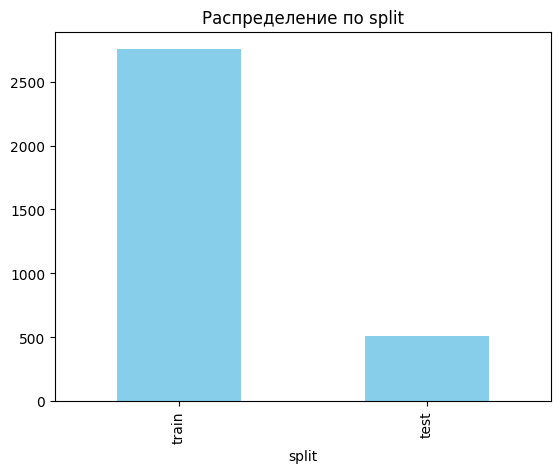

In [13]:
# Распределение по train/test
dish_df['split'].value_counts().plot(kind='bar', title='Распределение по split', color='skyblue')
plt.show()

Баланс между обучающей и тестовой выборками в порядке.

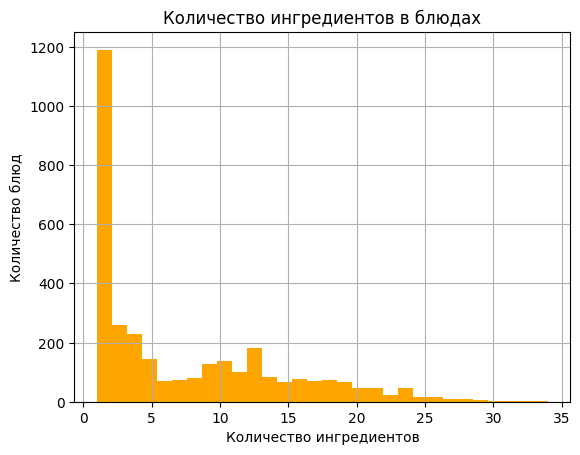

Среднее количество ингредиентов: 7.31
Мода (самое часто встречающееся): 1
Минимальное количество ингредиентов: 1
Максимальное количество ингредиентов: 34


In [14]:
# Количество ингредиентов
dish_df['n_ingredients'] = dish_df['ingredients'].apply(lambda x: len(x.split(';')))

# Гистограмма
dish_df['n_ingredients'].hist(bins=30, color='orange')
plt.title('Количество ингредиентов в блюдах')
plt.xlabel('Количество ингредиентов')
plt.ylabel('Количество блюд')
plt.show()

# Статистика
mean_val = dish_df['n_ingredients'].mean()
mode_val = stats.mode(dish_df['n_ingredients'], keepdims=False).mode  # keepdims=False возвращает скаляр
min_val = dish_df['n_ingredients'].min()
max_val = dish_df['n_ingredients'].max()

print(f"Среднее количество ингредиентов: {mean_val:.2f}")
print(f"Мода (самое часто встречающееся): {mode_val}")
print(f"Минимальное количество ингредиентов: {min_val}")
print(f"Максимальное количество ингредиентов: {max_val}")

Блюдо(а) с максимальным количеством ингредиентов: 34
Dish ID: dish_1561578461
Калорийность: 522 kcal
Масса: 392 g
Количество ингредиентов: 34
Ингредиенты: ['beef', 'salt', 'bell peppers', 'olive oil', 'cucumbers', 'lettuce', 'roasted potatoes', 'basil', 'thyme', 'garlic', 'rosemary', 'mushroom', 'arugula', 'pepper', 'cauliflower', 'olives', 'bok choy', 'cheese pizza', 'white wine', 'caesar salad', 'spinach (cooked)', 'butter', 'lemon juice', 'oregano', 'millet', 'vinaigrette', 'cherry tomatoes', 'shallots', 'onions', 'cream', 'feta cheese', 'vinegar', 'wheat berry', 'chicken']
----------------------------------------
Dish ID: dish_1561579933
Калорийность: 447 kcal
Масса: 306 g
Количество ингредиентов: 34
Ингредиенты: ['salt', 'cucumbers', 'olive oil', 'basil', 'onions', 'bell peppers', 'feta cheese', 'blueberries', 'chicken', 'shallots', 'spinach (cooked)', 'lemon juice', 'vinegar', 'chard', 'beef', 'white wine', 'walnuts', 'mustard', 'cream', 'wheat berry', 'oregano', 'cherry tomatoes

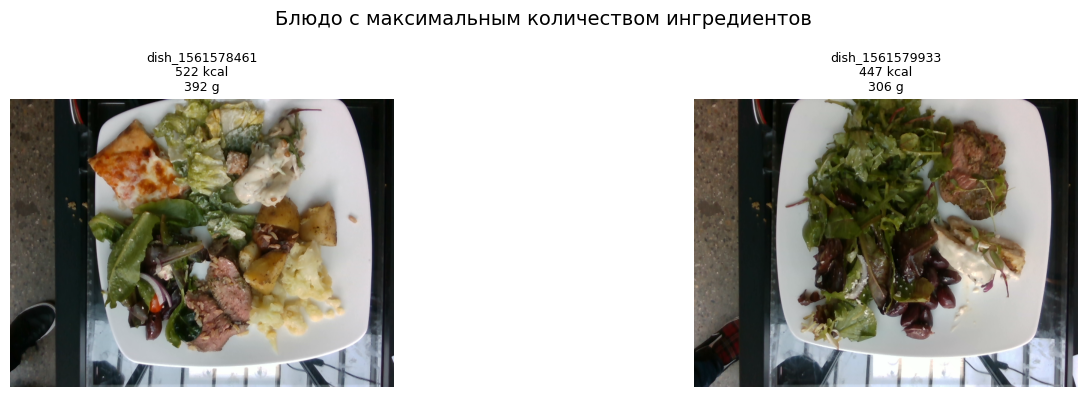

In [15]:
# Находим блюдо с максимальным количеством ингредиентов
dish_df['n_ingredients'] = dish_df['ingredients'].apply(lambda x: len(x.split(';')))
max_ingr = dish_df['n_ingredients'].max()
max_dish_df = dish_df[dish_df['n_ingredients'] == max_ingr]

print(f"Блюдо(а) с максимальным количеством ингредиентов: {max_ingr}")
for _, row in max_dish_df.iterrows():
    print(f"Dish ID: {row['dish_id']}")
    print(f"Калорийность: {row['total_calories']:.0f} kcal")
    print(f"Масса: {row['total_mass']:.0f} g")
    print(f"Количество ингредиентов: {row['n_ingredients']}")
    print(f"Ингредиенты: {[ingredients_df[ingredients_df['id'] == int(code.replace('ingr_', ''))]['ingr'].values[0] for code in row['ingredients'].split(';')]}")
    print("-" * 40)

# Показываем фотографию
show_dishes(max_dish_df, title="Блюдо с максимальным количеством ингредиентов")

При визуальном анализе подтвердить или опровергнуть количество ингредиентов не представляется возможным

📦 Всего блюд (папок): 3,490
🖼️ Всего изображений: 3,490
📌 Расширения изображений: {'.png': 3490}
📏 Средняя ширина: 640.0, средняя высота: 480.0
📊 Количество изображений в первых 10 папках:
  dish_1556572657: 1
  dish_1556573514: 1
  dish_1556575014: 1
  dish_1556575083: 1
  dish_1556575124: 1
  dish_1556575273: 1
  dish_1556575327: 1
  dish_1556575386: 1
  dish_1556575446: 1
  dish_1556575499: 1
📌 dish_1565370004: Размер=(640, 480), Режим=RGB, Формат=PNG
📌 dish_1558718009: Размер=(640, 480), Режим=RGB, Формат=PNG
📌 dish_1558114086: Размер=(640, 480), Режим=RGB, Формат=PNG
📌 dish_1566934487: Размер=(640, 480), Режим=RGB, Формат=PNG
📌 dish_1561404485: Размер=(640, 480), Режим=RGB, Формат=PNG


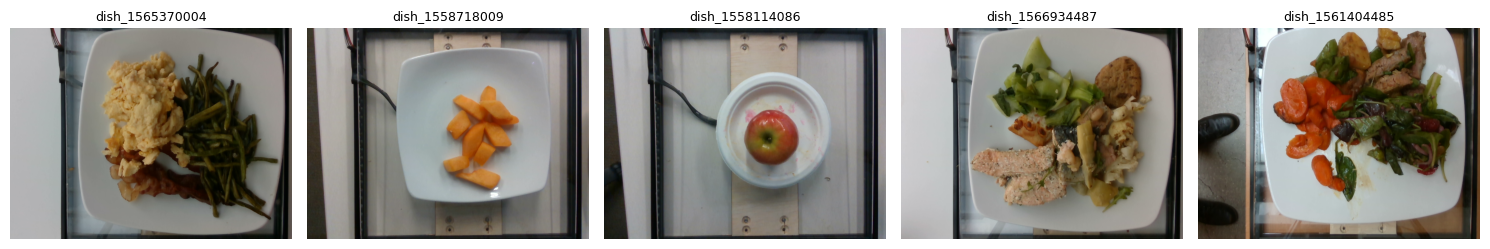

In [16]:
# === Список всех папок с блюдами ===
dish_folders = sorted([f for f in IMAGES_DIR.iterdir() if f.is_dir()])
print(f"📦 Всего блюд (папок): {len(dish_folders):,}")

# === Подсчет изображений в каждой папке и сбор расширений ===
image_counts = {}
extensions = []
sizes = []

for folder in dish_folders:
    imgs = list(folder.glob("*.*"))
    image_counts[folder.name] = len(imgs)
    for img_path in imgs:
        extensions.append(img_path.suffix.lower())
        with Image.open(img_path) as im:
            sizes.append(im.size)  # (width, height)

total_images = sum(image_counts.values())
print(f"🖼️ Всего изображений: {total_images:,}")

# === Распространение расширений ===
ext_counter = Counter(extensions)
print("📌 Расширения изображений:", dict(ext_counter))

# === Средние размеры ===
if sizes:
    widths, heights = zip(*sizes)
    print(f"📏 Средняя ширина: {np.mean(widths):.1f}, средняя высота: {np.mean(heights):.1f}")

# === Распределение количества изображений по папкам ===
print("📊 Количество изображений в первых 10 папках:")
for folder_name in list(image_counts.keys())[:10]:
    print(f"  {folder_name}: {image_counts[folder_name]}")

# === Вывод изображений случайных 5 блюд ===
random.seed(42)
n_samples = min(5, len(dish_folders))
sample_folders = random.sample(dish_folders, n_samples)

fig, axes = plt.subplots(1, n_samples, figsize=(15, 4))
for ax, folder in zip(axes, sample_folders):
    img_path = folder / "rgb.png"
    if img_path.exists():
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(folder.name, fontsize=9)
        ax.axis("off")
        print(f"📌 {folder.name}: Размер={img.size}, Режим={img.mode}, Формат={img.format}")
plt.tight_layout()
plt.show()

**План работ:**

**Подготовка данных:**

- Фильтрация некорректных блюд

- Генерация признаков: изображения → нормализация, текст → токенизация

**Архитектура модели:**

- Backbone для изображений (CNN или ViT)

- Encoder для текста (BERT/embedding)

- Фьюжн + Dense → регрессия

**Обучение:**

- Оптимизация MAE

- Аугментации для устойчивости

- Разделение на train/val для контроля переобучения

**Тестирование:**

- Оценка на test split

- Проверка, что MAE < 50

**Интеграция:**

- Модель сохраняется в продакшен-ready виде (PyTorch/TensorFlow + TorchScript/ONNX)

## Этап 2. Пайплайн обучения

### Подготовка датасета

In [17]:
# Функция для конкатенации ингредиентов
def get_ingredients_text(ingr_str):
    codes = ingr_str.split(';')
    names = [
        ingredients_df.loc[ingredients_df['id'] == int(c.replace('ingr_', '')), 'ingr'].values[0]
        for c in codes
    ]
    return ', '.join(names)

# Формируем новый df
df = pd.DataFrame()
df['dish_id'] = dish_df['dish_id']
df['image_path'] = dish_df['dish_id'].apply(lambda x: IMAGES_DIR / x / "rgb.png")
df['ingredients_text'] = dish_df['ingredients'].apply(get_ingredients_text)
df['total_calories'] = dish_df['total_calories']
df['total_mass'] = dish_df['total_mass']
df['n_ingredients'] = dish_df['ingredients'].apply(lambda x: len(x.split(';')))
df['split'] = dish_df['split']

# Оставляем только записи с существующими изображениями
df = df[df['image_path'].apply(lambda x: x.exists())].reset_index(drop=True)

print(f"Размер датасета: {df.shape}")



Размер датасета: (3260, 7)


In [18]:
df[df['dish_id'] == 'dish_1558376306']

,dish_id,image_path,ingredients_text,total_calories,total_mass,n_ingredients,split
54,dish_1558376306,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,sausage,372.167999,108.0,1,test


In [19]:
# Разделяем по split 
train_df = df[df['split'] == 'train'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)

# Размеры
print(f"Размер train: {train_df.shape}")
print(f"Размер test: {test_df.shape}\n")

# Первые 5 строк train
print("Train df head:")
display(train_df.head())

# Первые 5 строк test
print("Test df head:")
display(test_df.head())

Размер train: (2753, 7)
Размер test: (507, 7)

Train df head:


,dish_id,image_path,ingredients_text,total_calories,total_mass,n_ingredients,split
0,dish_1561662054,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,"pepper, white rice, mixed greens, garlic, soy ...",419.438782,292.0,17,train
1,dish_1560455030,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,"cherry tomatoes, cucumbers, baby carrots",20.590000,103.0,3,train
2,dish_1558372433,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,deprecated,74.360001,143.0,1,train
3,dish_1565640549,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,"tomatoes, cilantro, olive oil, mustard greens,...",45.482903,139.0,14,train
4,dish_1563207364,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,"scrambled eggs, yam, grapes, egg whites, olive...",309.269989,271.0,6,train


Test df head:


,dish_id,image_path,ingredients_text,total_calories,total_mass,n_ingredients,split
0,dish_1561662216,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,"soy sauce, garlic, white rice, parsley, onions...",300.794281,193.0,17,test
1,dish_1562008979,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,"jalapenos, lemon juice, pork, wheat berry, cab...",382.936646,290.0,13,test
2,dish_1561739238,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,"egg whites, hash browns, berries, sweet potato",274.190002,257.0,4,test
3,dish_1562691032,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,"berries, olive oil, pineapple, scrambled eggs,...",419.681702,415.0,6,test
4,dish_1558549773,C:\Files\AI\DLE\projects\dle_sprint_4\data\ima...,spinach (raw),2.300000,10.0,1,test


Матрица корреляций:
                total_calories  total_mass  n_ingredients
total_calories        1.000000    0.735789       0.492984
total_mass            0.735789    1.000000       0.471635
n_ingredients         0.492984    0.471635       1.000000


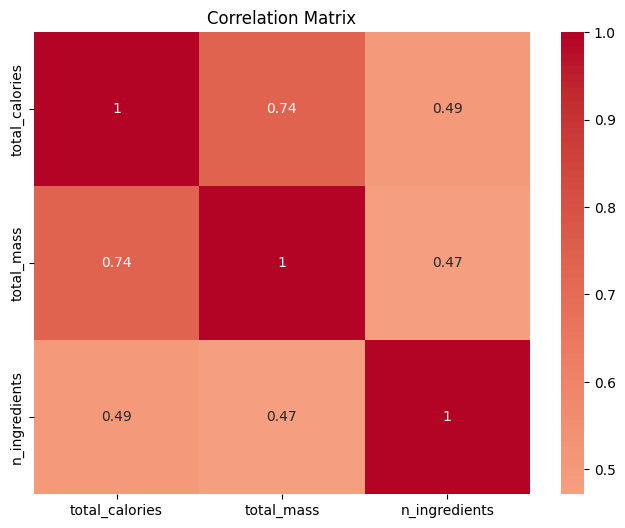

In [20]:
# Проверим корреляции
correlation_matrix = df[['total_calories', 'total_mass', 'n_ingredients']].corr()
print("Матрица корреляций:")
print(correlation_matrix)

# Визуализация
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [21]:
# Посмотрим на реальные данные
print("Статистики по данным:")
print(f"Correlation mass-calories: {df['total_mass'].corr(df['total_calories']):.3f}")
print(f"Correlation n_ingredients-calories: {df['n_ingredients'].corr(df['total_calories']):.3f}")

# Примеры блюд с одинаковой массой но разной калорийностью
same_mass = df[df['total_mass'].between(190, 210)]
if len(same_mass) > 1:
    print("\nБлюда с похожей массой но разной калорийностью:")
    print(same_mass[['total_mass', 'total_calories', 'ingredients_text']].head())

Статистики по данным:
Correlation mass-calories: 0.736
Correlation n_ingredients-calories: 0.493

Блюда с похожей массой но разной калорийностью:
     total_mass  total_calories  \
0         193.0      300.794281   
43        201.0      178.039185   
92        203.0      116.116005   
113       197.0      330.734009   
143       194.0      240.425751   

                                      ingredients_text  
0    soy sauce, garlic, white rice, parsley, onions...  
43   salt, pepper, blueberries, chard, arugula, vin...  
92                                               pears  
113                      spinach (raw), almonds, apple  
143  cilantro, ginger, spinach (raw), jalapenos, le...  


total_mass → total_calories: 0.736

Очень сильная корреляция - модель будет сильно зависеть от массы

Риск "ленивого обучения" - модель проигнорирует состав продуктов

### Обучение модели

In [22]:
# 1. Разделяем исходный train_df
train_df, val_df = train_test_split(
    train_df, 
    test_size=0.1,        
    random_state=config.SEED
)
# 3. Создаём DataLoaders
train_loader, val_loader, tokenizer, image_processor = create_dataloaders(train_df, val_df, config)


📊 Вычислена статистика целевой переменной:
   • MEAN: 253.79
   • STD: 209.85
   • Диапазон: [1.8, 1324.1]
   • Количество образцов: 2477
✅ Using fast tokenizer


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


📊 Numeric features stats:
   n_ingredients: mean=7.4, std=6.9
📊 Numeric features stats:
   n_ingredients: mean=7.0, std=6.6
✅ DataLoaders created: Train 2477 samples, Val 276 samples
📊 Using numeric features: n_ingredients


✅ Model initialized on cuda
📊 Using numeric features: n_ingredients
ДИАГНОСТИКА РАЗМОРОЗКИ

🎯 BGE Text Model: начинаем разморозку...
📊 BGE Text Model - ИТОГО:
   • Всего параметров: 391
   • Разморожено: 128 (32.7%)
   • Заморожено: 263
   • Размороженные слои: ['encoder.layer.16', 'encoder.layer.17', 'encoder.layer.18', 'encoder.layer.19', 'encoder.layer.20', 'encoder.layer.21', 'encoder.layer.22', 'encoder.layer.23']

🎯 DINOv2 Image Model: начинаем разморозку...
📊 DINOv2 Image Model - ИТОГО:
   • Всего параметров: 224
   • Разморожено: 93 (41.5%)
   • Заморожено: 131
   • Размороженные слои: ['encoder.layer.10', 'encoder.layer.11', 'encoder.layer.7', 'encoder.layer.8', 'encoder.layer.9', 'layernorm', 'register_tokens']

📈 СВОДНАЯ СТАТИСТИКА:
📝 Текстовая модель: 128/391 разморожено (32.7%)
🖼️  Изображенческая модель: 93/224 разморожено (41.5%)

🎯 ИТОГО ПО МОДЕЛИ:
   • Всего параметров: 422,723,969
   • Обучаемых: 137,219,969 (32.5%)
   • Замороженных: 285,504,000
🎯 Loss type: huber


C:\Files\AI\DLE\projects\dle_sprint_4\src\utils.py:393: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


📊 Используется статистика: mean=253.79, std=209.85


Epoch 1/100:   0%|          | 0/77 [00:00<?, ?it/s]C:\Files\AI\DLE\projects\dle_sprint_4\src\utils.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/100: 100%|██████████| 77/77 [00:25<00:00,  3.00it/s]



Epoch 1: Train MAE=90.2, Val MAE=49.9, Grad=2.124, NaN=0
💾 Saved best model (val_mae=49.9)


...


Epoch 31: Train MAE=11.0, Val MAE=27.9, Grad=0.107, NaN=0


Epoch 32/100: 100%|██████████| 77/77 [00:25<00:00,  3.03it/s]



Epoch 32: Train MAE=11.2, Val MAE=27.9, Grad=0.109, NaN=0


Epoch 33/100: 100%|██████████| 77/77 [00:25<00:00,  3.03it/s]



Epoch 33: Train MAE=10.8, Val MAE=27.8, Grad=0.107, NaN=0
⏹ Early stopping.

✅ Training finished. Best val_mae: 27.2


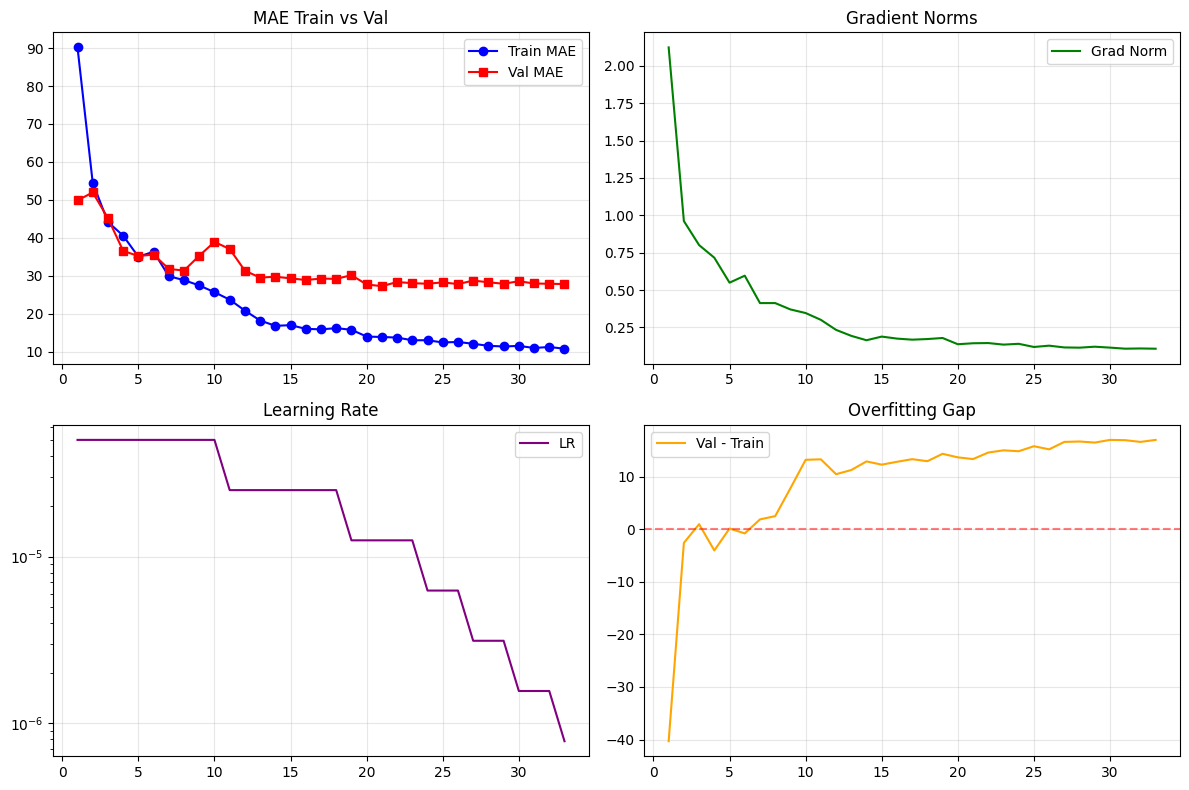

📈 Графики обучения сохранены.


In [23]:
model = train_regression(config, train_loader, val_loader)

## Этап 3. Валидация модели

📊 Numeric features stats:
   n_ingredients: mean=7.1, std=7.1


Testing on TEST dataset: 100%|██████████| 16/16 [00:05<00:00,  3.16it/s]



📊 TEST DATASET metrics: MAE=42.11, RMSE=68.80, R²=0.895
📊 Всего samples в test: 507

🔍 Детальный анализ ошибок на TEST DATASET:
  Медианная абсолютная ошибка: 23.8 калорий
  Средняя ошибка: -8.6 калорий
  Std ошибок: 68.3 калорий

🎯 Процент предсказаний в пределах:
  ± 10 калорий:  31.4%
  ± 20 калорий:  46.4%
  ± 30 калорий:  57.6%
  ± 50 калорий:  74.0%
  ±100 калорий:  89.5%

🔍 Топ-5 самых больших ошибок на TEST DATASET:
  1. Dish: dish_1566501575 | True:  251.7 | Pred:  673.3 | Error:   421.6
  2. Dish: dish_1565811139 | True:  902.2 | Pred:  554.1 | Error:  -348.1
  3. Dish: dish_1566414412 | True:  920.1 | Pred:  610.2 | Error:  -309.9
  4. Dish: dish_1563478751 | True:  950.4 | Pred:  696.8 | Error:  -253.6
  5. Dish: dish_1558373159 | True: 1013.3 | Pred:  770.0 | Error:  -243.3


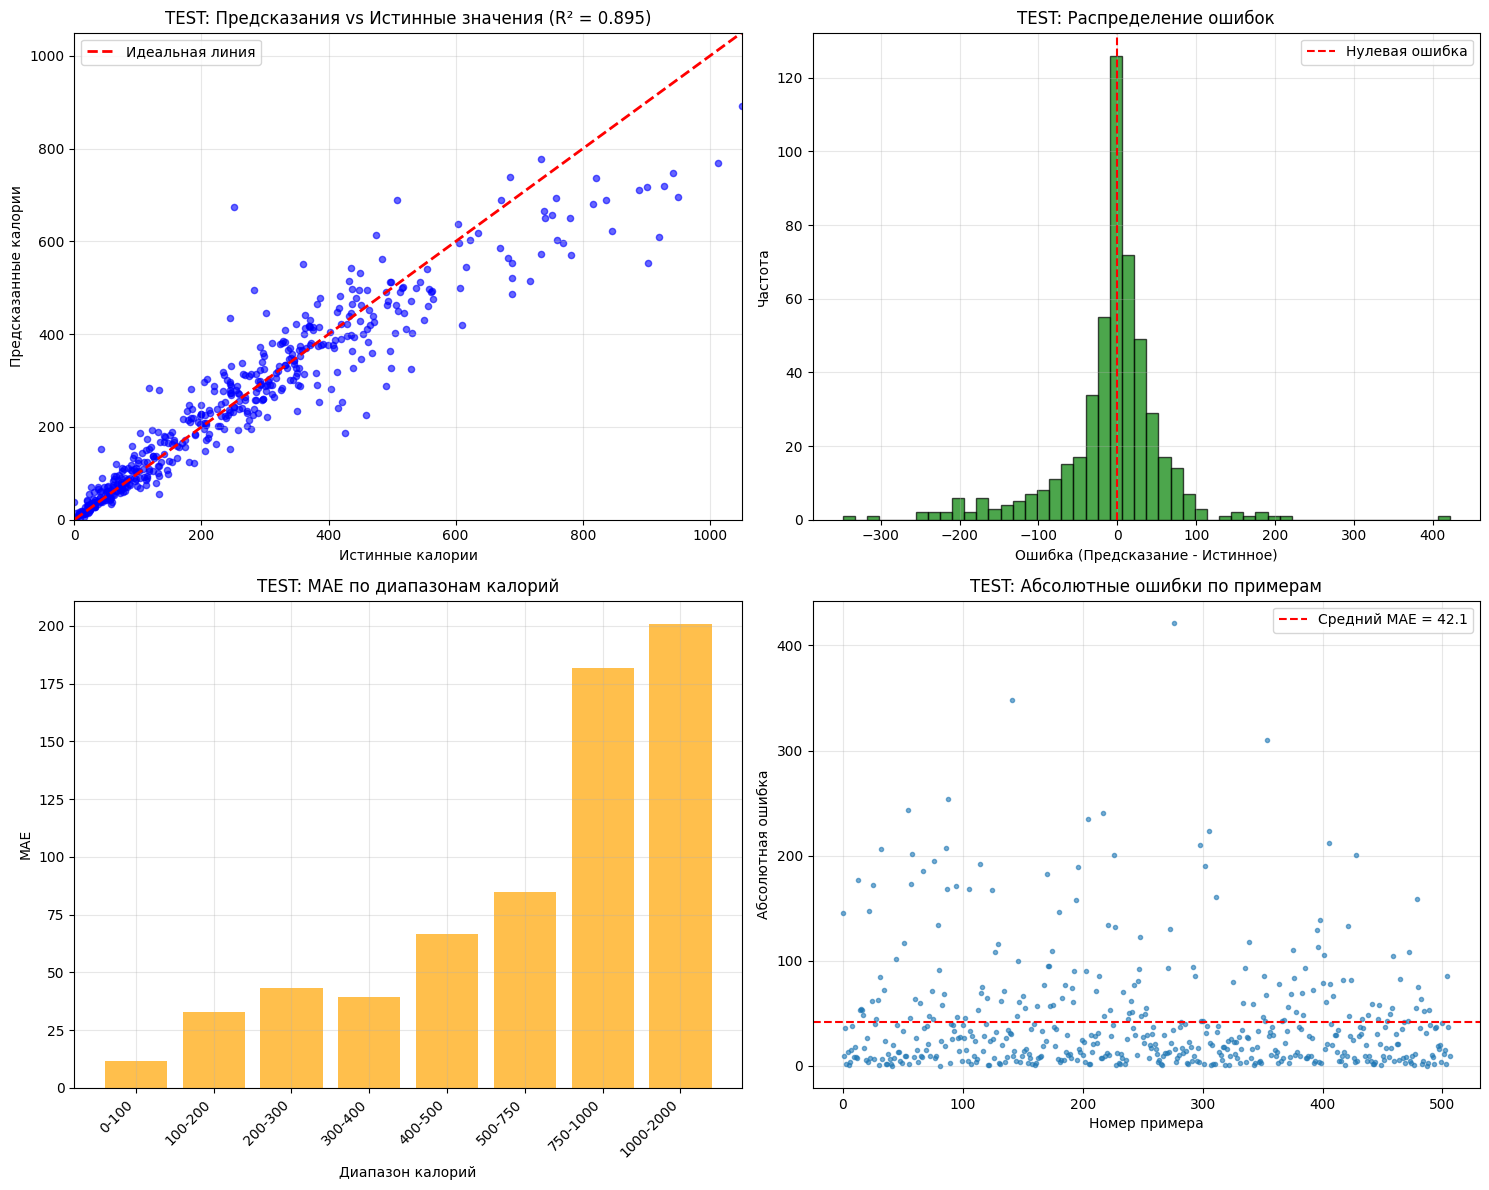


📋 Детальный анализ топ-5 ошибок на TEST DATASET:

1. 🍽️  Блюдо ID: dish_1566501575
   📊 Ошибка: 421.6 калорий (переоценка)
   🔢 Истинное значение: 251.7 калорий
   🤖 Предсказание: 673.3 калорий
   📈 Относительная ошибка: 167.5%
   ⚖️  Масса блюда: 54.0 грамм
   🥗 Количество ингредиентов: 1
   🥬 Ингредиенты: brownies
--------------------------------------------------------------------------------

2. 🍽️  Блюдо ID: dish_1565811139
   📊 Ошибка: 348.1 калорий (недооценка)
   🔢 Истинное значение: 902.2 калорий
   🤖 Предсказание: 554.1 калорий
   📈 Относительная ошибка: 38.6%
   ⚖️  Масса блюда: 416.0 грамм
   🥗 Количество ингредиентов: 6
   🥬 Ингредиенты: carrot, goat cheese, olive oil, broccoli, spinach (raw), chicken
--------------------------------------------------------------------------------

3. 🍽️  Блюдо ID: dish_1566414412
   📊 Ошибка: 309.9 калорий (недооценка)
   🔢 Истинное значение: 920.1 калорий
   🤖 Предсказание: 610.2 калорий
   📈 Относительная ошибка: 33.7%
   ⚖️  Масса блю

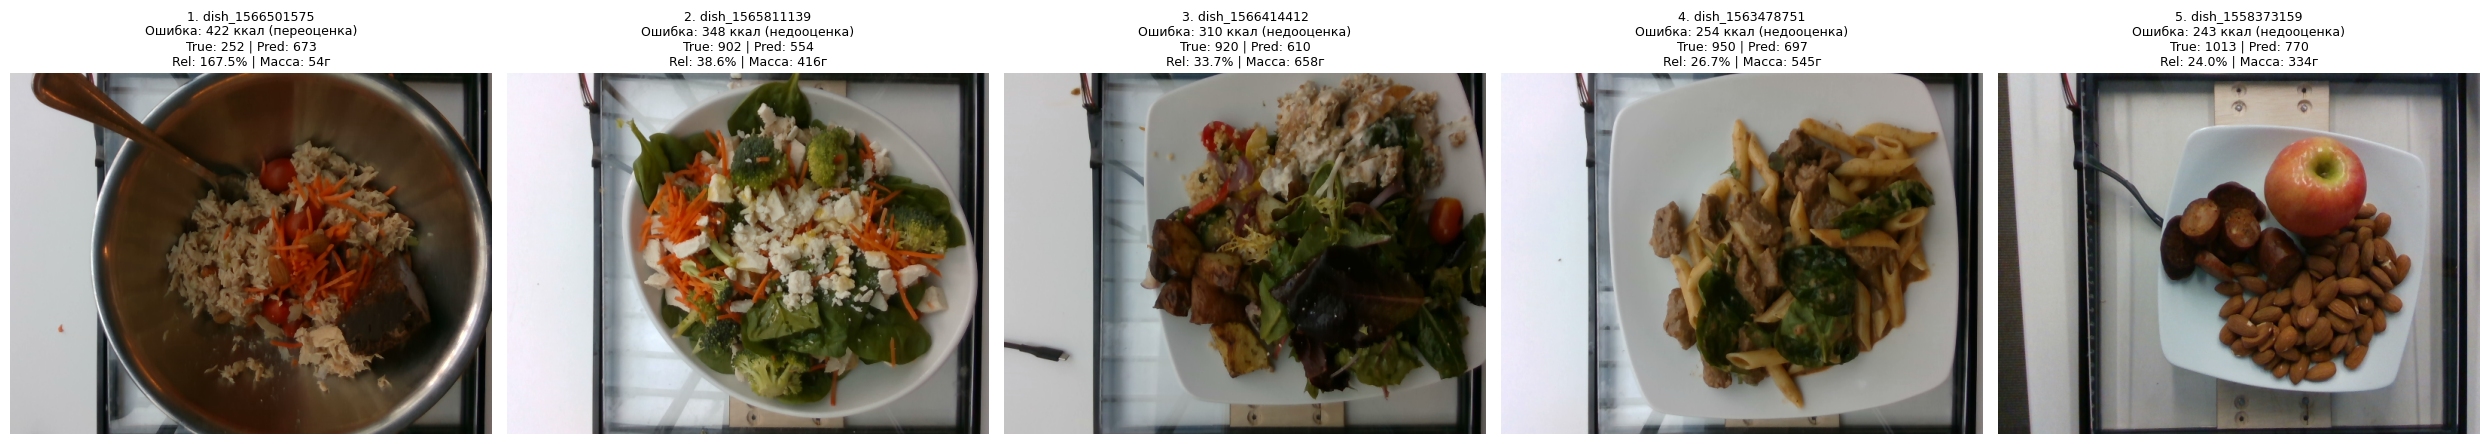

In [24]:
# === ТЕСТИРОВАНИЕ НА TEST DATASET ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Диапазоны калорий для анализа ===
calorie_ranges = [0, 200, 400, 600, 800, 1000, 2000]

# === Функция анализа ошибок по диапазонам ===
def analyze_by_ranges(y_true, y_pred, ranges):
    results = []
    for i in range(len(ranges) - 1):
        mask = (y_true >= ranges[i]) & (y_true < ranges[i+1])
        if mask.sum() == 0:
            continue  # пропускаем диапазоны без данных
        mae = mean_absolute_error(y_true[mask], y_pred[mask])
        results.append((f"{ranges[i]}-{ranges[i+1]}", mae, mask.sum()))
    return results

# --- DataLoader для test данных ---
test_loader = DataLoader(
    MultimodalDataset(
        test_df,  # ← используем test_df вместо val_df
        get_transforms(config.IMAGE_MODEL, config.IMAGE_SIZE, "eval"),
        config=config
    ),
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    collate_fn=partial(
        collate_fn,
        tokenizer=tokenizer,
        image_processor=image_processor,
        max_length=config.MAX_SEQ_LENGTH,
        config=config
    ),
    num_workers=0,
    pin_memory=True
)

# --- Инференс на test данных ---
all_preds, all_labels, all_indices = [], [], []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing on TEST dataset"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)

        numeric_features = batch.get("numeric")
        if numeric_features is not None:
            numeric_features = numeric_features.to(device)

        labels = batch["label"].to(device)
        indices = batch["indices"]
        
        preds_norm = model(input_ids, attention_mask, images, numeric_features)
        preds = preds_norm * config.TARGET_STD + config.TARGET_MEAN

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_indices.extend(indices)

# Конвертируем в numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Метрики на TEST данных ---
mae = mean_absolute_error(all_labels, all_preds)
rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
r2 = r2_score(all_labels, all_preds)

print(f"\n📊 TEST DATASET metrics: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.3f}")
print(f"📊 Всего samples в test: {len(all_labels)}")

# === ДЕТАЛЬНЫЙ АНАЛИЗ НА TEST ДАННЫХ ===
print(f"\n🔍 Детальный анализ ошибок на TEST DATASET:")
print("=" * 60)

# Базовые ошибки
errors = all_preds - all_labels
abs_errors = np.abs(errors)

print(f"  Медианная абсолютная ошибка: {np.median(abs_errors):.1f} калорий")
print(f"  Средняя ошибка: {np.mean(errors):.1f} калорий")
print(f"  Std ошибок: {np.std(errors):.1f} калорий")

# Анализ по диапазонам калорий
calorie_ranges = [0, 100, 200, 300, 400, 500, 750, 1000, 2000, 4000]
analyze_by_ranges(all_labels, all_preds, calorie_ranges)

# Процент точных попаданий
print(f"\n🎯 Процент предсказаний в пределах:")
for threshold in [10, 20, 30, 50, 100]:
    within = np.sum(abs_errors <= threshold) / len(abs_errors) * 100
    print(f"  ±{threshold:3d} калорий: {within:5.1f}%")

# Топ-5 ошибок на TEST данных
print(f"\n🔍 Топ-5 самых больших ошибок на TEST DATASET:")
sorted_indices = np.argsort(abs_errors)[::-1][:5]

for i, error_idx in enumerate(sorted_indices):
    original_df_idx = all_indices[error_idx]
    dish_info = test_df.iloc[original_df_idx]  # ← используем test_df
    
    true_val = all_labels[error_idx]
    pred_val = all_preds[error_idx]
    error = errors[error_idx]
    
    print(f"  {i+1}. Dish: {dish_info['dish_id']} | True: {true_val:6.1f} | Pred: {pred_val:6.1f} | Error: {error:7.1f}")

# === ВИЗУАЛИЗАЦИЯ ДЛЯ TEST ДАННЫХ ===
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Предсказания vs Истинные значения
axes[0,0].scatter(all_labels, all_preds, alpha=0.6, s=20, color='blue')
max_val = max(all_labels.max(), all_preds.max(), 1000)
axes[0,0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Идеальная линия')
axes[0,0].set_xlim(0, max_val)
axes[0,0].set_ylim(0, max_val)
axes[0,0].set_xlabel('Истинные калории')
axes[0,0].set_ylabel('Предсказанные калории')
axes[0,0].set_title(f'TEST: Предсказания vs Истинные значения (R² = {r2:.3f})')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Распределение ошибок
axes[0,1].hist(errors, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0,1].axvline(0, color='red', linestyle='--', label='Нулевая ошибка')
axes[0,1].set_xlabel('Ошибка (Предсказание - Истинное)')
axes[0,1].set_ylabel('Частота')
axes[0,1].set_title('TEST: Распределение ошибок')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. MAE по диапазонам калорий
mae_by_range = []
range_labels = []
for i in range(len(calorie_ranges)-1):
    low, high = calorie_ranges[i], calorie_ranges[i+1]
    mask = (all_labels >= low) & (all_labels < high)
    if mask.sum() > 0:
        mae_range = mean_absolute_error(all_labels[mask], all_preds[mask])
        mae_by_range.append(mae_range)
        range_labels.append(f'{low}-{high}')

axes[1,0].bar(range(len(mae_by_range)), mae_by_range, alpha=0.7, color='orange')
axes[1,0].set_xlabel('Диапазон калорий')
axes[1,0].set_ylabel('MAE')
axes[1,0].set_title('TEST: MAE по диапазонам калорий')
axes[1,0].set_xticks(range(len(mae_by_range)))
axes[1,0].set_xticklabels(range_labels, rotation=45, ha='right')
axes[1,0].grid(True, alpha=0.3)

# 4. Абсолютные ошибки по порядку
axes[1,1].plot(abs_errors, 'o', alpha=0.6, markersize=3)
axes[1,1].axhline(y=mae, color='red', linestyle='--', label=f'Средний MAE = {mae:.1f}')
axes[1,1].set_xlabel('Номер примера')
axes[1,1].set_ylabel('Абсолютная ошибка')
axes[1,1].set_title('TEST: Абсолютные ошибки по примерам')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === ДЕТАЛЬНЫЙ АНАЛИЗ ТОП ОШИБОК НА TEST ДАННЫХ ===
print(f"\n📋 Детальный анализ топ-5 ошибок на TEST DATASET:")
print("=" * 80)

for i, error_idx in enumerate(sorted_indices):
    original_df_idx = all_indices[error_idx]
    dish_info = test_df.iloc[original_df_idx]  # ← используем test_df
    
    print(f"\n{i+1}. 🍽️  Блюдо ID: {dish_info['dish_id']}")
    print(f"   📊 Ошибка: {abs_errors[error_idx]:.1f} калорий ({'переоценка' if errors[error_idx] > 0 else 'недооценка'})")
    print(f"   🔢 Истинное значение: {all_labels[error_idx]:.1f} калорий")
    print(f"   🤖 Предсказание: {all_preds[error_idx]:.1f} калорий")
    if all_labels[error_idx] > 0:
        print(f"   📈 Относительная ошибка: {abs_errors[error_idx]/all_labels[error_idx]*100:.1f}%")
    print(f"   ⚖️  Масса блюда: {dish_info['total_mass']:.1f} грамм")
    print(f"   🥗 Количество ингредиентов: {dish_info['n_ingredients']}")
    
    # Обрезаем длинный список ингредиентов
    ingredients = dish_info['ingredients_text']
    if len(ingredients) > 150:
        ingredients = ingredients[:147] + "..."
    
    print(f"   🥬 Ингредиенты: {ingredients}")
    print("-" * 80)

# === ФИНАЛЬНАЯ СТАТИСТИКА ДЛЯ TEST ДАННЫХ ===
print(f"\n📈 Финальная статистика для TEST DATASET:")
print("=" * 50)
print(f"📊 Основные метрики:")
print(f"  MAE: {mae:.2f} калорий")
print(f"  RMSE: {rmse:.2f} калорий") 
print(f"  R²: {r2:.3f}")

print(f"\n🎯 Качество предсказаний:")
within_20 = np.sum(abs_errors <= 20) / len(abs_errors) * 100
within_50 = np.sum(abs_errors <= 50) / len(abs_errors) * 100
print(f"  В пределах 20 калорий: {within_20:.1f}%")
print(f"  В пределах 50 калорий: {within_50:.1f}%")

print(f"\n📊 Распределение ошибок:")
print(f"  Переоценка: {np.sum(errors > 0) / len(errors) * 100:.1f}%")
print(f"  Недооценка: {np.sum(errors < 0) / len(errors) * 100:.1f}%")
print(f"  Точно: {np.sum(errors == 0) / len(errors) * 100:.1f}%")

print(f"\n✅ Тестирование на TEST DATASET завершено!")

# === ДЕТАЛЬНЫЙ АНАЛИЗ ТОП ОШИБОК НА TEST ДАННЫХ ===
print(f"\n📋 Детальный анализ топ-5 ошибок на TEST DATASET:")
print("=" * 80)

# === ВИЗУАЛИЗАЦИЯ ТОП-5 ОШИБОК (В ОДНУ СТРОКУ) ===
print(f"\n🖼️ Визуализация топ-5 ошибок на TEST DATASET:")
print("=" * 80)

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for i, error_idx in enumerate(sorted_indices):
    original_df_idx = all_indices[error_idx]
    dish_info = test_df.iloc[original_df_idx]
    
    true_val = all_labels[error_idx]
    pred_val = all_preds[error_idx]
    abs_error = abs_errors[error_idx]
    rel_error = abs_error / true_val * 100 if true_val > 0 else 0
    err_type = "переоценка" if errors[error_idx] > 0 else "недооценка"
    
    img_path = dish_info.get("image_path")
    if img_path and os.path.exists(img_path):
        img = plt.imread(img_path)
    else:
        img = np.ones((224, 224, 3))  # заглушка

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"{i+1}. {dish_info['dish_id']}\n"
        f"Ошибка: {abs_error:.0f} ккал ({err_type})\n"
        f"True: {true_val:.0f} | Pred: {pred_val:.0f}\n"
        f"Rel: {rel_error:.1f}% | Масса: {dish_info['total_mass']:.0f}г",
        fontsize=9
    )

plt.tight_layout()
plt.show()


In [25]:
print("\n🧠 Анализ возможных причин крупных ошибок:")
print("=" * 80)

for i, error_idx in enumerate(sorted_indices[:5]):
    dish = test_df.iloc[all_indices[error_idx]]
    true_val, pred_val = all_labels[error_idx], all_preds[error_idx]
    abs_error = abs_errors[error_idx]
    rel_error = abs_error / true_val * 100 if true_val > 0 else 0
    err_type = "переоценка" if pred_val > true_val else "недооценка"

    reasons = []
    
    # --- Возможные причины ---
    if dish["n_ingredients"] <= 2:
        reasons.append("слишком мало ингредиентов → модель не может извлечь богатые признаки")
    if dish["total_mass"] < 100:
        reasons.append("очень малая масса блюда → чувствительность к абсолютным ошибкам")
    if dish["total_mass"] > 500:
        reasons.append("большой вес блюда → калорийность масштабируется нелинейно")
    if "cream" in dish["ingredients_text"] or "oil" in dish["ingredients_text"]:
        reasons.append("высококалорийные ингредиенты, которые трудно точно оценить визуально")
    if rel_error > 100:
        reasons.append("экстремальное отклонение — вероятно, ошибка аннотации или неверная масса")
    if len(reasons) == 0:
        reasons.append("возможно, ограниченная обобщающая способность модели на этот тип блюда")

    print(f"{i+1}. 🍽️ {dish['dish_id']} ({err_type}, ошибка {abs_error:.1f} ккал, {rel_error:.1f}%)")
    for r in reasons:
        print(f"   • {r}")
    print("-" * 80)



🧠 Анализ возможных причин крупных ошибок:
1. 🍽️ dish_1566501575 (переоценка, ошибка 421.6 ккал, 167.5%)
   • слишком мало ингредиентов → модель не может извлечь богатые признаки
   • очень малая масса блюда → чувствительность к абсолютным ошибкам
   • экстремальное отклонение — вероятно, ошибка аннотации или неверная масса
--------------------------------------------------------------------------------
2. 🍽️ dish_1565811139 (недооценка, ошибка 348.1 ккал, 38.6%)
   • высококалорийные ингредиенты, которые трудно точно оценить визуально
--------------------------------------------------------------------------------
3. 🍽️ dish_1566414412 (недооценка, ошибка 309.9 ккал, 33.7%)
   • большой вес блюда → калорийность масштабируется нелинейно
   • высококалорийные ингредиенты, которые трудно точно оценить визуально
--------------------------------------------------------------------------------
4. 🍽️ dish_1563478751 (недооценка, ошибка 253.6 ккал, 26.7%)
   • большой вес блюда → калорийность